<a href="https://colab.research.google.com/github/springboardmentor14065l/Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights/blob/Nikhil-yadav/week%201-2/Data_Cleaning_and_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/energy.csv")
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour
df['Minute'] = df['Timestamp'].dt.minute
df = df.drop(['Date', 'Time'], axis=1)
cols = ['Timestamp'] + [c for c in df.columns if c != 'Timestamp']
df = df[cols]
df.to_csv("energy_data_with_timestamp.csv", index=False)
df.head()

,Timestamp,Home ID,Appliance Type,Energy Consumption (kWh),Outdoor Temperature (°C),Season,Household Size,Year,Month,Day,Hour,Minute
0,2023-12-02 21:12:00,94,Fridge,0.20,-1.0,Fall,2,2023,12,2,21,12
1,2023-08-06 20:11:00,435,Oven,0.23,31.1,Summer,5,2023,8,6,20,11
2,2023-11-21 06:39:00,466,Dishwasher,0.32,21.3,Fall,3,2023,11,21,6,39
3,2023-01-21 21:56:00,496,Heater,3.92,-4.2,Winter,1,2023,1,21,21,56
4,2023-08-26 04:31:00,137,Microwave,0.44,34.5,Summer,5,2023,8,26,4,31


In [9]:
energy_col = "Energy Consumption (kWh)"
Q1 = df[energy_col].quantile(0.25)
Q3 = df[energy_col].quantile(0.75)
IQR = Q3 - Q1
df = df[
    (df[energy_col] >= Q1 - 1.5 * IQR) &
    (df[energy_col] <= Q3 + 1.5 * IQR)
]


In [10]:
X = df.drop(columns=['Energy Consumption (kWh)'])
y = df['Energy Consumption (kWh)']


In [17]:
import pandas as pd

# Ensure 'Timestamp' is the index and is of DatetimeIndex type for resampling
if not isinstance(df.index, pd.DatetimeIndex):
    if 'Timestamp' in df.columns:
        df = df.set_index('Timestamp')
        df = df.sort_index()
    else:
        raise KeyError("Timestamp column not found to set as index for resampling.")

numeric_df = df.select_dtypes(include=['number'])
df_hourly = numeric_df.resample('h').mean()
df_hourly = df_hourly.ffill() # Updated to use .ffill() instead of .fillna(method='ffill')
print(df_hourly.head())

                      Home ID  Energy Consumption (kWh)  \
Timestamp                                                 
2023-01-01 00:00:00  323.4000                  1.148000   
2023-01-01 01:00:00  272.0000                  1.280000   
2023-01-01 02:00:00  206.9375                  1.641875   
2023-01-01 03:00:00  285.0000                  1.520000   
2023-01-01 04:00:00  246.9000                  1.561000   

                     Outdoor Temperature (°C)  Household Size    Year  Month  \
Timestamp                                                                      
2023-01-01 00:00:00                  13.35000        3.000000  2023.0    1.0   
2023-01-01 01:00:00                  23.95000        3.142857  2023.0    1.0   
2023-01-01 02:00:00                  19.83125        2.437500  2023.0    1.0   
2023-01-01 03:00:00                  24.56250        2.875000  2023.0    1.0   
2023-01-01 04:00:00                  13.91000        2.900000  2023.0    1.0   

                     Day 

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_hourly[['Energy Consumption (kWh)']] = scaler.fit_transform(
    df_hourly[['Energy Consumption (kWh)']]
)

# Check result
print(df_hourly['Energy Consumption (kWh)'].min())
print(df_hourly['Energy Consumption (kWh)'].max())


0.0
1.0000000000000002


In [15]:
X = df_hourly.drop('Energy Consumption (kWh)', axis=1)
y = df_hourly['Energy Consumption (kWh)']


In [16]:
train_size = int(len(df_hourly) * 0.70)
val_size = int(len(df_hourly) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]


# Task
Plot `y_train`, `y_val`, and `y_test` to visually represent the temporal split of the energy consumption data, with each set shown in a distinct color.

## Visualize Data Splits

### Subtask:
Plot the `y_train`, `y_val`, and `y_test` sets to visually represent the temporal split of the energy consumption data. Each set will be shown with a distinct color to clearly differentiate training, validation, and testing periods.


**Reasoning**:
To visualize the temporal split of the energy consumption data, I will plot `y_train`, `y_val`, and `y_test` with distinct colors and appropriate labels using `matplotlib`.



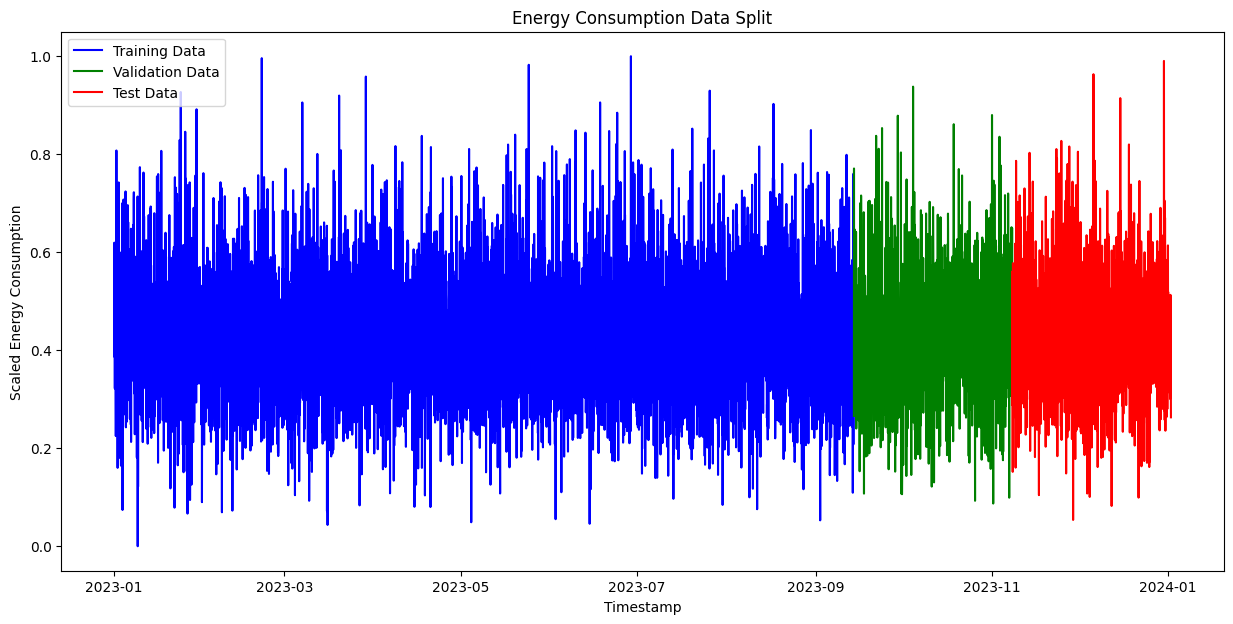

In [18]:
import matplotlib.pyplot as plt

# Create a figure and an axes object for plotting
plt.figure(figsize=(15, 7))

# Plot y_train
plt.plot(y_train.index, y_train, color='blue', label='Training Data')

# Plot y_val
plt.plot(y_val.index, y_val, color='green', label='Validation Data')

# Plot y_test
plt.plot(y_test.index, y_test, color='red', label='Test Data')

# Add title and labels
plt.title('Energy Consumption Data Split')
plt.xlabel('Timestamp')
plt.ylabel('Scaled Energy Consumption')

# Add a legend
plt.legend()

# Display the plot
plt.show()

## Summary:

### Data Analysis Key Findings

*   The energy consumption data was successfully split into three distinct sets: training (`y_train`), validation (`y_val`), and testing (`y_test`).
*   The visualization clearly shows these splits in chronological order, with `y_train` appearing first (blue), followed by `y_val` (green), and finally `y_test` (red), indicating a temporal data split crucial for time-series analysis.
*   Each data set was plotted with a distinct color, allowing for clear visual differentiation between the training, validation, and test periods.

### Insights or Next Steps

*   The successful visualization confirms that the energy consumption data has been correctly partitioned temporally, which is essential for developing robust time-series forecasting models.
*   The next logical step is to proceed with model development and training using the `y_train` set, fine-tuning hyperparameters with `y_val`, and finally evaluating the model's performance on the unseen `y_test` data.
